In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
size = 50
moisture = np.random.rand(size,size)

In [3]:
def tree(density,size):
    tree = np.random.choice([0,1], size = (size,size), p = [1-density, density])
    return tree

In [4]:
def diffuse (m, D=0.1):
    new_m = m.copy()
    for i in range(1, size-1):
        for j in range(1,size-1):
            neighbors = [m[i+1,j],m[i-1,j],m[i,j+1],m[i,j-1]]
            new_m[i,j]+= D*(np.sum(neighbors) - 4*m[i,j])
    return new_m

In [5]:
def uptake(m, trees, rate=0.05):
    return m - rate*trees

In [6]:
#values of evap_wilting and evap_max need to be verified
def evapotranspiration(m,trees, evap_wilting = 0.01, evap_max=0.03, maxevap_pt = 0.4, wilting_pt = 0.15, hygroscopic_pt = 0.05):
    new_m = m.copy()
    for i in range(size):
        for j in range(size):
            if m[i,j] <= hygroscopic_pt:
                new_m[i,j] = m[i,j]
            elif m[i,j] <= wilting_pt:
                new_m[i,j] = m[i,j]*(1 - evap_wilting*((m[i,j]- hygroscopic_pt)/(wilting_pt - hygroscopic_pt)))
            elif m[i,j] <= maxevap_pt:
                new_m[i,j] = m[i,j]*(1 - evap_wilting - (evap_max - evap_wilting)*((m[i,j] - wilting_pt)/(maxevap_pt - wilting_pt)))
            else:
                new_m[i,j] = m[i,j]*(1 - evap_max)
    return np.clip(new_m,0,None)

In [7]:
def rain_input(m, trees, lam=0.1, interception=2):
    new_m = m.copy()
    rain_today = np.random.poisson(lam)>0
    if rain_today:
        depth = np.random.exponential(15)
        for i in range(size):
            for j in range(size):
                if trees[i,j]==1:
                    new_m[i,j] = max(m[i,j], m[i,j] + (depth - interception))
                else:
                    new_m[i,j] = m[i,j] + depth
    return new_m

In [8]:
def season_temperature(day):   #constant temperature per season
    if day < 90:  #winter
        return 8.0
    elif day<181:  #spring
        return 16.0
    elif day<273:  #summer
        return 24.0
    else:          #autumn
        return 14.0

In [9]:
def evaporation(state, trees, day, evap_base = 0.002, temp_sensitivity = 0.0005, shade_factor=0.1):
    temp = season_temperature(day)

    evap_rate = evap_base + temp_sensitivity*temp           #evaporation increases with temperature
    shade_multiplier = 1 - (shade_factor*trees)               #shade reduces evaporation where trees are present

    new_state = state - evap_rate*shade_multiplier

    return np.clip(new_state,0,None)

In [10]:
def final_moisture(m, trees, lam=0.1, interception=2, evap_wilting=0.01, evap_max=0.03, maxevap_pt = 0.4, wilting_pt = 0.15, hygroscopic_pt = 0.05, evap_base = 0.002, temp_sensitivity = 0.0005, shade_factor=0.1, D=0.1, sweeps=365):
    state = m.copy()
    for t in range(sweeps):
        state = diffuse(state,D)
        state = evapotranspiration(state, trees, evap_wilting, evap_max, maxevap_pt, wilting_pt, hygroscopic_pt)
        state = rain_input(state, trees, lam, interception)
        state = evaporation(state, trees, t, evap_base, temp_sensitivity, shade_factor)
    return state

In [11]:
def average_moisture(m, trees, lam=0.1, interception=2,
                     evap_wilting=0.01, evap_max=0.03,
                     maxevap_pt=0.4, wilting_pt=0.15, hygroscopic_pt=0.05,
                     evap_base=0.002, temp_sensitivity=0.0005,
                     shade_factor=0.1, D=0.1, sweeps=365):

    final_state = final_moisture(
        m, trees,
        lam=lam,
        interception=interception,
        evap_wilting=evap_wilting,
        evap_max=evap_max,
        maxevap_pt=maxevap_pt,
        wilting_pt=wilting_pt,
        hygroscopic_pt=hygroscopic_pt,
        evap_base=evap_base,
        temp_sensitivity=temp_sensitivity,
        shade_factor=shade_factor,
        D=D,
        sweeps=sweeps
    )
    return np.mean(final_state)

[np.float64(18.347309314449607), np.float64(34.60062619470051), np.float64(85.40890027606216), np.float64(52.64581797639092), np.float64(54.32281566981777), np.float64(30.66425079652261), np.float64(27.145761751427322), np.float64(75.3627587520676), np.float64(21.472637151332336), np.float64(43.98051348228744), np.float64(33.79466709784827), np.float64(42.42403770614667), np.float64(7.739057877072798), np.float64(38.67179989047873), np.float64(79.41036976964135), np.float64(82.13627717439427), np.float64(33.331484151224075), np.float64(33.25572218577695), np.float64(40.566088834407), np.float64(29.294051773245634), np.float64(62.498441508302136), np.float64(102.82292920941713), np.float64(21.577338907279163), np.float64(24.1778563436859), np.float64(23.031923599155665), np.float64(31.90048459171232), np.float64(20.3431045183313), np.float64(22.517734595531685), np.float64(73.33943784546462), np.float64(68.82729648027102), np.float64(65.41454322981339), np.float64(39.131847782977644), n

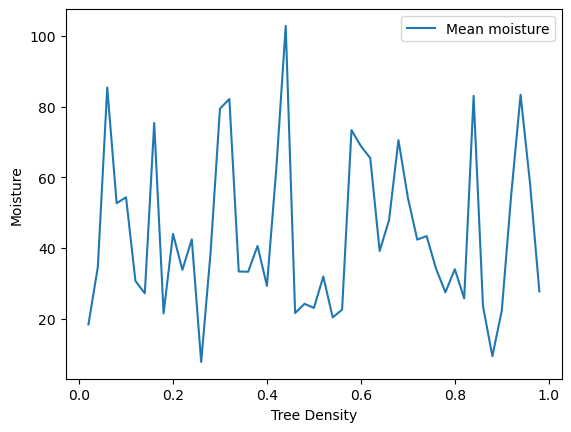

In [12]:
mean_moisture = []
density_list = []
for d in range(1,50):
    density = d* 0.02
    trees = tree(density,50)
    final_state = final_moisture(moisture, trees, lam=0.1, interception=2, evap_wilting=0.01, evap_max=0.03, maxevap_pt = 0.4, wilting_pt = 0.15, hygroscopic_pt = 0.05, evap_base=0.002, temp_sensitivity=0.0005,shade_factor=1.0, D=0.1, sweeps=365)
    average = average_moisture(
    moisture, trees,
    lam=0.1,
    interception=2,
    evap_wilting=0.01,
    evap_max=0.03,
    maxevap_pt=0.4,
    wilting_pt=0.15,
    hygroscopic_pt=0.05,
    evap_base=0.002,
    temp_sensitivity=0.0005,
    shade_factor=1.0,
    D=0.1,
    sweeps=365
)
    mean_moisture.append(average)
    density_list.append(density)

print(mean_moisture)

plt.plot(density_list, mean_moisture, label = "Mean moisture")
plt.legend()
plt.xlabel("Tree Density")
plt.ylabel("Moisture")
plt.show()